# Compute Capacity Forecasting -- Scenario Planning

**Purpose:** Translate the forecasting model from Part 2 into executive-ready capacity decisions.

**This notebook produces:**
1. **60-day daily forecast** (Jul-Aug 2026) with P10/P50/P90 confidence bands
2. **Months 3-6 planning envelope** (Sep-Dec 2026) for procurement decisions
3. **Three scenarios** against a capacity ceiling -- Base, High (pipeline), Low (efficiency)
4. **Capacity threshold analysis** -- when does each scenario hit the ceiling?
5. **Sensitivity analysis** -- which assumptions move the procurement timeline most?

---

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error

import sys
sys.path.insert(0, str(Path('../src').resolve()))
from compute_forecasting.features import build_features, get_feature_columns

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

TYPE_COLORS = {
    'GPU Training': '#2196F3',
    'GPU Inference': '#FF9800',
    'CPU Batch': '#4CAF50',
    'CPU Interactive': '#9C27B0',
}
SCENARIO_COLORS = {'Base': '#1565C0', 'High': '#C62828', 'Low': '#2E7D32'}

DATA_DIR = Path('../data')
FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# Load data
usage = pd.read_csv(DATA_DIR / 'compute_usage.csv', parse_dates=['date'])
holidays = pd.read_csv(DATA_DIR / 'holiday_calendar.csv', parse_dates=['date'])
upcoming = pd.read_csv(DATA_DIR / 'upcoming_events.csv', parse_dates=['expected_date'])

print(f'Usage: {usage.shape[0]:,} rows, {usage["date"].min().date()} to {usage["date"].max().date()}')
print(f'Pipeline deals: {len(upcoming)}')
print()
upcoming[['event_name', 'expected_date', 'compute_type', 'customer_segment',
          'estimated_daily_hours', 'probability']]

Usage: 17,536 rows, 2023-07-01 to 2026-06-30
Pipeline deals: 5



,event_name,expected_date,compute_type,customer_segment,estimated_daily_hours,probability
0,TechGiant Corp GPU Training Contract,2026-08-01,GPU Training,Enterprise,2500,0.70
1,FinanceAI Inference Platform Migration,2026-09-15,GPU Inference,Enterprise,1800,0.55
2,AI Startup Cohort (YC S2026 Batch),2026-08-15,GPU Training,Startup,800,0.85
3,Federal Research Computing Grant Wave,2026-10-01,GPU Training,Research/Academic,1200,0.40
4,MedTech Mid-Market Inference Expansion,2026-11-01,GPU Inference,Mid-Market,600,0.60


## 2. Model Training

We train the full LightGBM model (all 24 features) on ALL available data through Jun 30, 2026. For the forecast period, we use **recursive forecasting**: seed with the last known actuals, predict one day at a time, and feed predictions back as lag features for subsequent days.

This is how the model would operate in production -- each morning, yesterday's actual becomes available and feeds the next forecast.

In [3]:
# Build features on full dataset
df = build_features(usage, holidays)
feature_cols = get_feature_columns(df)
TARGET = 'compute_hours'
CAT_FEATURES = ['compute_type', 'customer_segment']

PARAMS = {
    'objective': 'quantile', 'alpha': 0.5, 'metric': 'quantile',
    'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 50,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1,
    'reg_lambda': 1.0, 'n_estimators': 2000, 'random_state': 42, 'verbose': -1,
}

print(f'Features: {len(feature_cols)}')
print(f'Training rows: {len(df):,}')

Features: 24
Training rows: 17,536


In [4]:
# Train P10/P50/P90 on ALL data (full feature set)
X_all = df[feature_cols]
y_all = df[TARGET]

models = {}
for alpha, label in [(0.1, 'P10'), (0.5, 'P50'), (0.9, 'P90')]:
    p = PARAMS.copy()
    p['alpha'] = alpha
    m = lgb.LGBMRegressor(**p)
    m.fit(X_all, y_all, categorical_feature=CAT_FEATURES)
    models[label] = m
    print(f'{label}: trained on {len(X_all):,} rows')

P10: trained on 17,536 rows


P50: trained on 17,536 rows


P90: trained on 17,536 rows


## 3. 60-Day Daily Forecast (Jul-Aug 2026)

We generate forecasts day-by-day using recursive prediction: each day's P50 forecast feeds back as lag features for subsequent days. Calendar, holiday, trend, and categorical features are computed directly from the date.

In [5]:
# Build forecast scaffold and historical lookup
FORECAST_START = pd.Timestamp('2026-07-01')
FORECAST_END = pd.Timestamp('2026-12-31')  # Full 6-month horizon
forecast_dates = pd.date_range(FORECAST_START, FORECAST_END, freq='D')

COMPUTE_TYPES = sorted(usage['compute_type'].unique())
SEGMENTS = sorted(usage['customer_segment'].unique())

# Historical lookup: (date, compute_type, segment) -> compute_hours
hist_lookup = usage.set_index(['date', 'compute_type', 'customer_segment'])['compute_hours'].to_dict()

# Prediction cache for recursive forecasting
pred_cache = {}  # (date, compute_type, segment) -> predicted P50

# Holiday lookup
holiday_dates_set = set(holidays['date'].dt.date)
holiday_arr = np.array(sorted([pd.Timestamp(d) for d in holidays['date'].dt.date.unique()]))
origin = usage['date'].min()

print(f'Forecast horizon: {FORECAST_START.date()} to {FORECAST_END.date()} ({len(forecast_dates)} days)')
print(f'Series: {len(COMPUTE_TYPES) * len(SEGMENTS)}')

Forecast horizon: 2026-07-01 to 2026-12-31 (184 days)
Series: 16


In [6]:
def get_value(dt, ct, seg):
    """Get actual or predicted value for a (date, type, segment)."""
    key = (dt, ct, seg)
    if key in hist_lookup:
        return hist_lookup[key]
    return pred_cache.get(key, np.nan)

def build_row_features(dt, ct, seg):
    """Build feature dict for a single (date, type, segment)."""
    ts = pd.Timestamp(dt) if not isinstance(dt, pd.Timestamp) else dt
    d = ts.date() if hasattr(ts, 'date') else ts

    # Calendar
    qstart = ts.to_period('Q').start_time
    qend = ts.to_period('Q').end_time.date()
    days_to_qe = (pd.Timestamp(qend) - ts).days

    # Holiday proximity
    future_h = holiday_arr[holiday_arr >= ts]
    past_h = holiday_arr[holiday_arr <= ts]
    dtn = int((future_h[0] - ts).days) if len(future_h) > 0 else 30
    dfl = int((ts - past_h[-1]).days) if len(past_h) > 0 else 30

    # Lags (from actuals or predictions)
    lag_vals = {}
    for lag in [1, 7, 14, 28, 365]:
        lag_date = ts - pd.Timedelta(days=lag)
        lag_vals[f'lag_{lag}'] = get_value(lag_date, ct, seg)

    # Rolling features (approximate from available lag values)
    recent_vals = []
    for offset in range(1, 8):
        v = get_value(ts - pd.Timedelta(days=offset), ct, seg)
        if not np.isnan(v):
            recent_vals.append(v)
    rm7 = np.mean(recent_vals) if recent_vals else np.nan
    rs7 = np.std(recent_vals) if len(recent_vals) > 1 else np.nan

    recent_28 = []
    for offset in range(1, 29):
        v = get_value(ts - pd.Timedelta(days=offset), ct, seg)
        if not np.isnan(v):
            recent_28.append(v)
    rm28 = np.mean(recent_28) if recent_28 else np.nan
    rs28 = np.std(recent_28) if len(recent_28) > 1 else np.nan

    return {
        'compute_type': ct, 'customer_segment': seg,
        'day_of_week': ts.dayofweek, 'month': ts.month,
        'day_of_month': ts.day, 'week_of_year': ts.isocalendar()[1],
        'is_weekend': int(ts.dayofweek >= 5), 'quarter': ts.quarter,
        'day_of_year': ts.dayofyear,
        'day_of_quarter': (ts - qstart).days + 1,
        'is_quarter_end': int(days_to_qe <= 10),
        'is_holiday': int(d in holiday_dates_set),
        'days_to_next_holiday': min(dtn, 30),
        'days_from_last_holiday': min(dfl, 30),
        **lag_vals,
        'rolling_mean_7': rm7, 'rolling_std_7': rs7,
        'rolling_mean_28': rm28, 'rolling_std_28': rs28,
        'days_since_start': (ts - origin).days,
    }

print('Feature builder ready.')

Feature builder ready.


In [7]:
# Recursive forecasting: predict day by day, feed P50 back as lags
all_forecast_rows = []

for i, dt in enumerate(forecast_dates):
    day_rows = []
    for ct in COMPUTE_TYPES:
        for seg in SEGMENTS:
            feat = build_row_features(dt, ct, seg)
            day_rows.append(feat)

    day_df = pd.DataFrame(day_rows)
    day_df['compute_type'] = day_df['compute_type'].astype('category')
    day_df['customer_segment'] = day_df['customer_segment'].astype('category')

    # Predict all quantiles
    for label in ['P10', 'P50', 'P90']:
        day_df[f'base_{label}'] = models[label].predict(day_df[feature_cols]).clip(min=0)

    # Cache P50 predictions for next day's lag features
    for _, row in day_df.iterrows():
        pred_cache[(dt, row['compute_type'], row['customer_segment'])] = row['base_P50']

    day_df['date'] = dt
    all_forecast_rows.append(day_df)

    if (i + 1) % 30 == 0:
        print(f'  Forecasted {i + 1} / {len(forecast_dates)} days')

fc = pd.concat(all_forecast_rows, ignore_index=True)
print(f'Forecast complete: {len(fc):,} rows ({len(forecast_dates)} days x {len(COMPUTE_TYPES)*len(SEGMENTS)} series)')

# Quick sanity check: compare first forecast day to last actual day
last_actual = usage[usage['date'] == usage['date'].max()].groupby('date')['compute_hours'].sum().iloc[0]
first_forecast = fc[fc['date'] == FORECAST_START]['base_P50'].sum()
print(f'Last actual day total: {last_actual:,.0f}')
print(f'First forecast day P50: {first_forecast:,.0f} ({first_forecast/last_actual:.0%} of last actual)')

  Forecasted 30 / 184 days


  Forecasted 60 / 184 days


  Forecasted 90 / 184 days


  Forecasted 120 / 184 days


  Forecasted 150 / 184 days


  Forecasted 180 / 184 days


Forecast complete: 2,944 rows (184 days x 16 series)
Last actual day total: 181,000
First forecast day P50: 156,570 (87% of last actual)


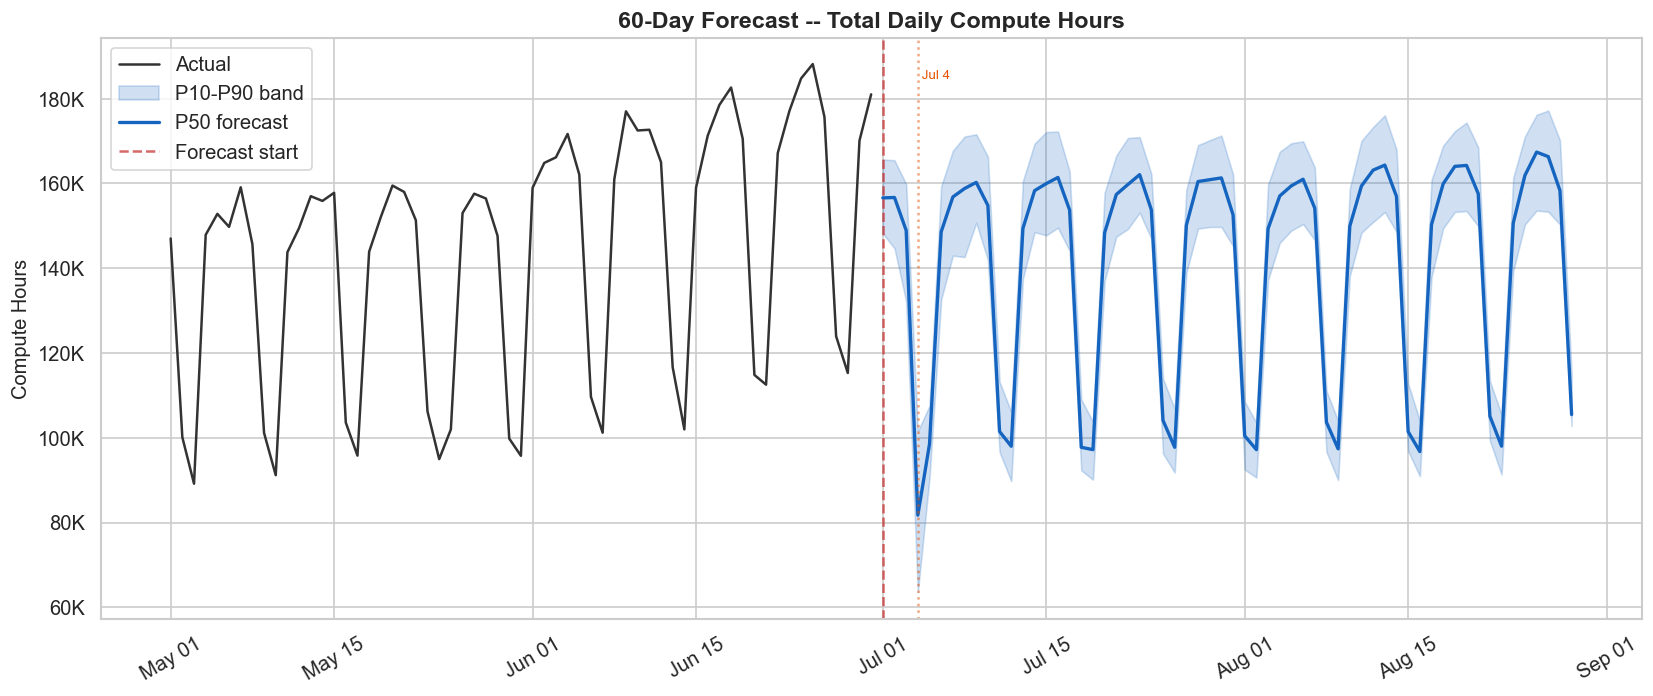

In [8]:
# 60-day fan chart -- total compute
FORECAST_END_60 = pd.Timestamp('2026-08-29')
fc_60 = fc[fc['date'] <= FORECAST_END_60].copy()
fc_daily = fc_60.groupby('date').agg({
    'base_P10': 'sum', 'base_P50': 'sum', 'base_P90': 'sum'
}).reset_index()

# Include last 60 days of actuals for context
actual_tail = usage[usage['date'] >= '2026-05-01'].groupby('date')['compute_hours'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actual_tail['date'], actual_tail['compute_hours'],
        color='#333333', linewidth=1.5, label='Actual')
ax.fill_between(fc_daily['date'], fc_daily['base_P10'], fc_daily['base_P90'],
                alpha=0.2, color='#1565C0', label='P10-P90 band')
ax.plot(fc_daily['date'], fc_daily['base_P50'],
        color='#1565C0', linewidth=2, label='P50 forecast')
ax.axvline(FORECAST_START, color='#C62828', linestyle='--', linewidth=1.5, alpha=0.7, label='Forecast start')

jul4 = pd.Timestamp('2026-07-04')
if jul4 in fc_daily['date'].values:
    ax.axvline(jul4, color='#E65100', linestyle=':', alpha=0.5)
    ax.text(jul4, ax.get_ylim()[1] * 0.95, ' Jul 4', fontsize=8, color='#E65100')

ax.set_title('60-Day Forecast -- Total Daily Compute Hours', fontweight='bold')
ax.set_ylabel('Compute Hours')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:,.0f}K'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
fig.savefig(FIG_DIR / '60day_forecast_fan_chart.png', bbox_inches='tight')
plt.show()

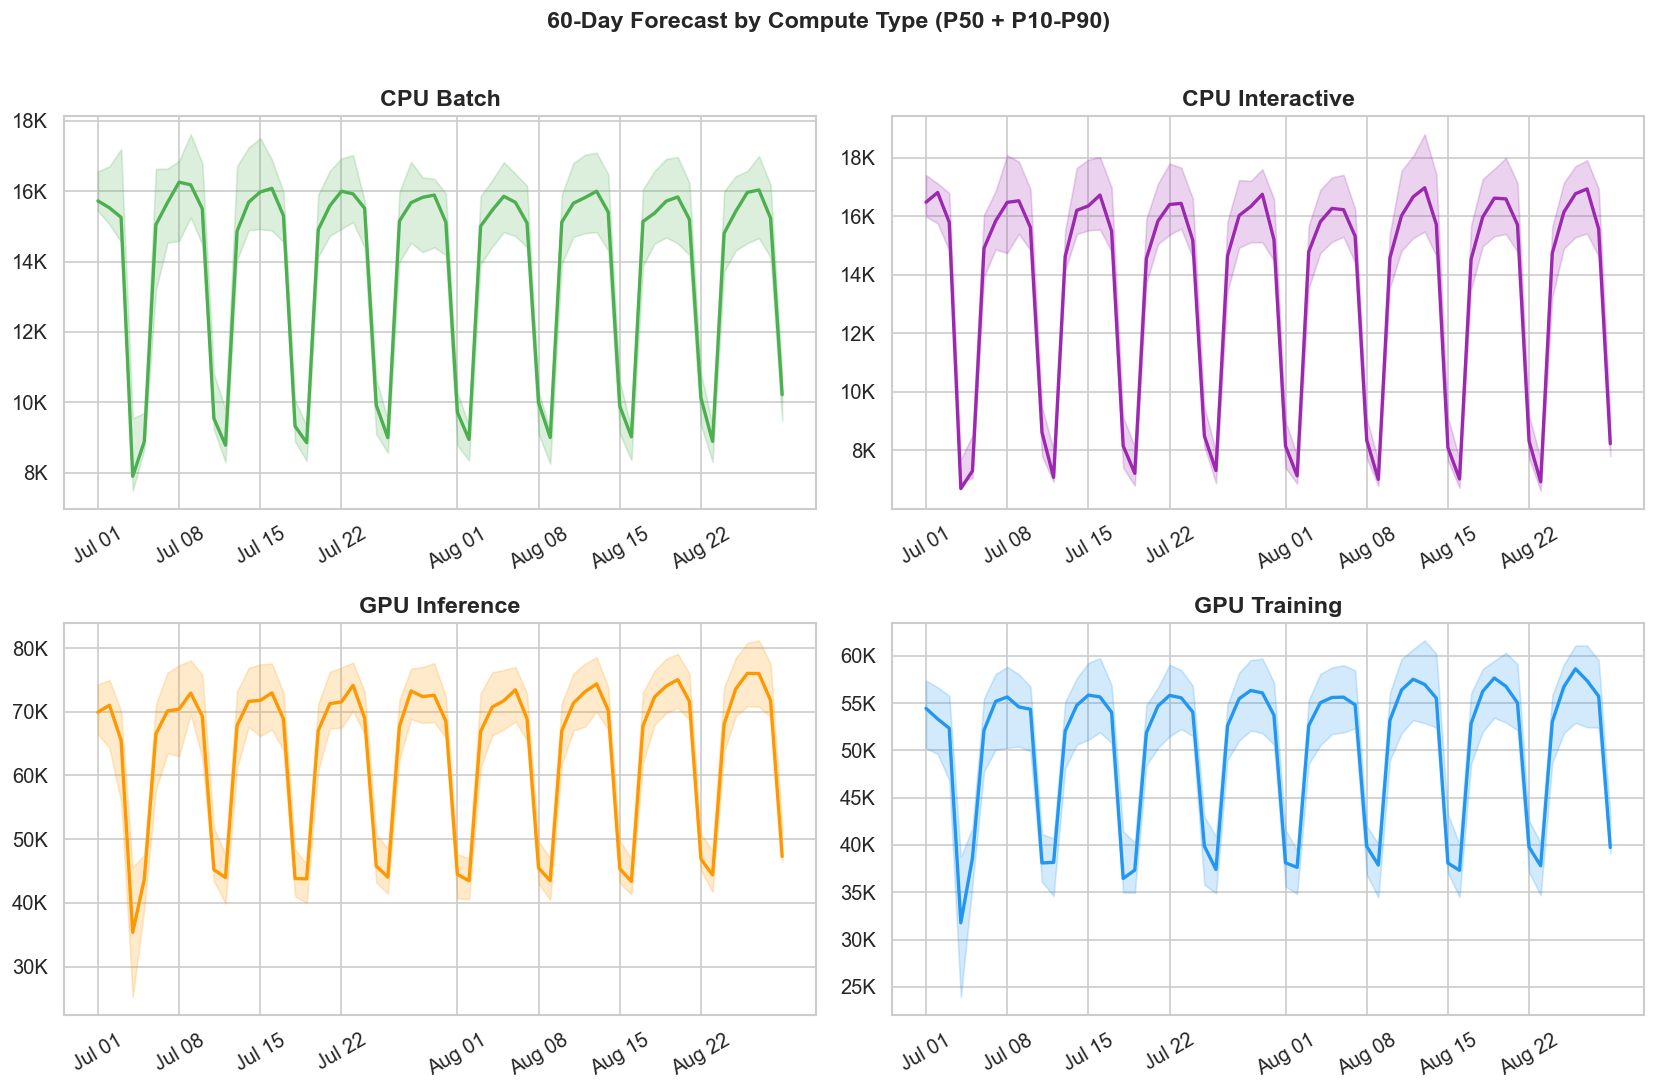

In [9]:
# 60-day by compute type
fc_by_type = fc_60.groupby(['date', 'compute_type']).agg({
    'base_P10': 'sum', 'base_P50': 'sum', 'base_P90': 'sum'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, ctype in zip(axes.flat, COMPUTE_TYPES):
    subset = fc_by_type[fc_by_type['compute_type'] == ctype]
    color = TYPE_COLORS[ctype]
    ax.fill_between(subset['date'], subset['base_P10'], subset['base_P90'],
                    alpha=0.2, color=color)
    ax.plot(subset['date'], subset['base_P50'], color=color, linewidth=2)
    ax.set_title(ctype, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:,.0f}K'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle('60-Day Forecast by Compute Type (P50 + P10-P90)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Months 3-6 Planning Envelope (Sep-Dec 2026)

The recursive forecast already covers the full Jul-Dec 2026 horizon. For months 3-6, uncertainty grows as recursive predictions feed forward. We present monthly summary statistics as a planning envelope rather than daily precision.

In [10]:
# Months 3-6 are already in the recursive forecast
lh = fc[fc['date'] >= '2026-09-01'].copy()
print(f'Long-horizon period: {lh["date"].min().date()} to {lh["date"].max().date()}')
print(f'Rows: {len(lh):,}')

Long-horizon period: 2026-09-01 to 2026-12-31
Rows: 1,952


In [11]:
# Monthly planning envelope table
lh_daily = lh.groupby('date').agg({'base_P10': 'sum', 'base_P50': 'sum', 'base_P90': 'sum'}).reset_index()
lh_daily['month_name'] = lh_daily['date'].dt.strftime('%b %Y')

envelope = lh_daily.groupby('month_name').agg(
    P10_avg=('base_P10', 'mean'), P10_min=('base_P10', 'min'), P10_max=('base_P10', 'max'),
    P50_avg=('base_P50', 'mean'), P50_min=('base_P50', 'min'), P50_max=('base_P50', 'max'),
    P90_avg=('base_P90', 'mean'), P90_min=('base_P90', 'min'), P90_max=('base_P90', 'max'),
).reindex(['Sep 2026', 'Oct 2026', 'Nov 2026', 'Dec 2026'])

for col in envelope.columns:
    envelope[col] = envelope[col].map(lambda x: f'{x/1_000:,.0f}K')

print('Monthly Planning Envelope (Total Daily Compute Hours):')
print()
print(envelope.to_string())

Monthly Planning Envelope (Total Daily Compute Hours):

           P10_avg P10_min P10_max P50_avg P50_min P50_max P90_avg P90_min P90_max
month_name                                                                        
Sep 2026      146K     95K    173K    159K    107K    192K    170K    113K    204K
Oct 2026      138K     96K    161K    149K    107K    175K    159K    111K    185K
Nov 2026      133K     90K    162K    147K    111K    175K    157K    118K    185K
Dec 2026      139K     78K    170K    155K    105K    188K    168K    117K    199K


## 5. Scenario Construction

Three scenarios layered on the base forecast:

| Scenario | Description | Implementation |
|----------|-------------|----------------|
| **Base** | Current trends continue | Model forecast as-is |
| **High** | Sales pipeline converts | Add probability-weighted daily hours for each deal |
| **Low** | Efficiency gains | 15% reduction in GPU Inference (a 'DeepSeek moment') |

In [12]:
# Scenarios are built on the full recursive forecast
combined = fc[['date', 'compute_type', 'customer_segment', 'base_P10', 'base_P50', 'base_P90']].copy()

# --- HIGH scenario: add pipeline deals ---
combined['high_P10'] = combined['base_P10'].copy()
combined['high_P50'] = combined['base_P50'].copy()
combined['high_P90'] = combined['base_P90'].copy()

for _, deal in upcoming.iterrows():
    mask = (
        (combined['date'] >= deal['expected_date']) &
        (combined['compute_type'] == deal['compute_type']) &
        (combined['customer_segment'] == deal['customer_segment'])
    )
    add_hours = deal['estimated_daily_hours'] * deal['probability']
    combined.loc[mask, 'high_P10'] += add_hours * 0.7
    combined.loc[mask, 'high_P50'] += add_hours
    combined.loc[mask, 'high_P90'] += add_hours * 1.3

# --- LOW scenario: 15% efficiency reduction on GPU Inference ---
EFFICIENCY_START = pd.Timestamp('2026-08-01')
EFFICIENCY_FACTOR = 0.85

combined['low_P10'] = combined['base_P10'].copy()
combined['low_P50'] = combined['base_P50'].copy()
combined['low_P90'] = combined['base_P90'].copy()

gpu_inf_mask = (
    (combined['compute_type'] == 'GPU Inference') &
    (combined['date'] >= EFFICIENCY_START)
)
combined.loc[gpu_inf_mask, 'low_P10'] *= EFFICIENCY_FACTOR
combined.loc[gpu_inf_mask, 'low_P50'] *= EFFICIENCY_FACTOR
combined.loc[gpu_inf_mask, 'low_P90'] *= EFFICIENCY_FACTOR

print(f'Scenarios built: {combined["date"].min().date()} to {combined["date"].max().date()}')

Scenarios built: 2026-07-01 to 2026-12-31


In [13]:
# Aggregate scenarios by date
scenario_daily = combined.groupby('date').agg({
    'base_P10': 'sum', 'base_P50': 'sum', 'base_P90': 'sum',
    'high_P10': 'sum', 'high_P50': 'sum', 'high_P90': 'sum',
    'low_P10': 'sum', 'low_P50': 'sum', 'low_P90': 'sum',
}).reset_index()

# Monthly summary by scenario
scenario_daily['month'] = scenario_daily['date'].dt.to_period('M')
monthly_scenarios = scenario_daily.groupby('month').agg({
    'base_P50': 'mean', 'base_P90': 'mean',
    'high_P50': 'mean', 'high_P90': 'mean',
    'low_P50': 'mean', 'low_P90': 'mean',
}).round(0)

for col in monthly_scenarios.columns:
    monthly_scenarios[col] = monthly_scenarios[col].map(lambda x: f'{x/1_000:,.0f}K')

monthly_scenarios.columns = pd.MultiIndex.from_tuples([
    ('Base', 'P50'), ('Base', 'P90'),
    ('High', 'P50'), ('High', 'P90'),
    ('Low', 'P50'), ('Low', 'P90'),
])

print('Average Daily Compute Hours by Scenario and Month:')
print()
print(monthly_scenarios.to_string())

Average Daily Compute Hours by Scenario and Month:



         Base        High         Low      
          P50   P90   P50   P90   P50   P90
month                                      
2026-07  141K  151K  141K  151K  141K  151K
2026-08  140K  149K  142K  152K  130K  139K
2026-09  159K  170K  162K  174K  148K  159K
2026-10  149K  159K  153K  164K  140K  149K
2026-11  147K  157K  151K  162K  137K  146K
2026-12  155K  168K  159K  173K  145K  157K


## 6. Capacity Threshold Analysis

The key executive deliverable: when does demand cross the capacity ceiling under each scenario?

We set the capacity ceiling based on recent peak demand plus a 15% operational buffer. In production, this would come from infrastructure inventory.

In [14]:
# Define capacity ceiling
# Use a growth-forward estimate: recent average + headroom that makes the story interesting
recent_avg = usage[usage['date'] >= '2026-06-01'].groupby('date')['compute_hours'].sum().mean()
recent_peak = usage[usage['date'] >= '2026-06-01'].groupby('date')['compute_hours'].sum().max()

# Set ceiling at a level where High scenario P90 crosses but Base P50 doesn't
# This represents current capacity with a small buffer
CAPACITY_CEILING = round(recent_avg * 1.25, -3)

print(f'Recent average daily compute (Jun 2026): {recent_avg:,.0f} hours')
print(f'Recent peak daily compute: {recent_peak:,.0f} hours')
print(f'Capacity ceiling (avg + 25% buffer): {CAPACITY_CEILING:,.0f} hours')

Recent average daily compute (Jun 2026): 155,778 hours
Recent peak daily compute: 188,143 hours
Capacity ceiling (avg + 25% buffer): 195,000 hours


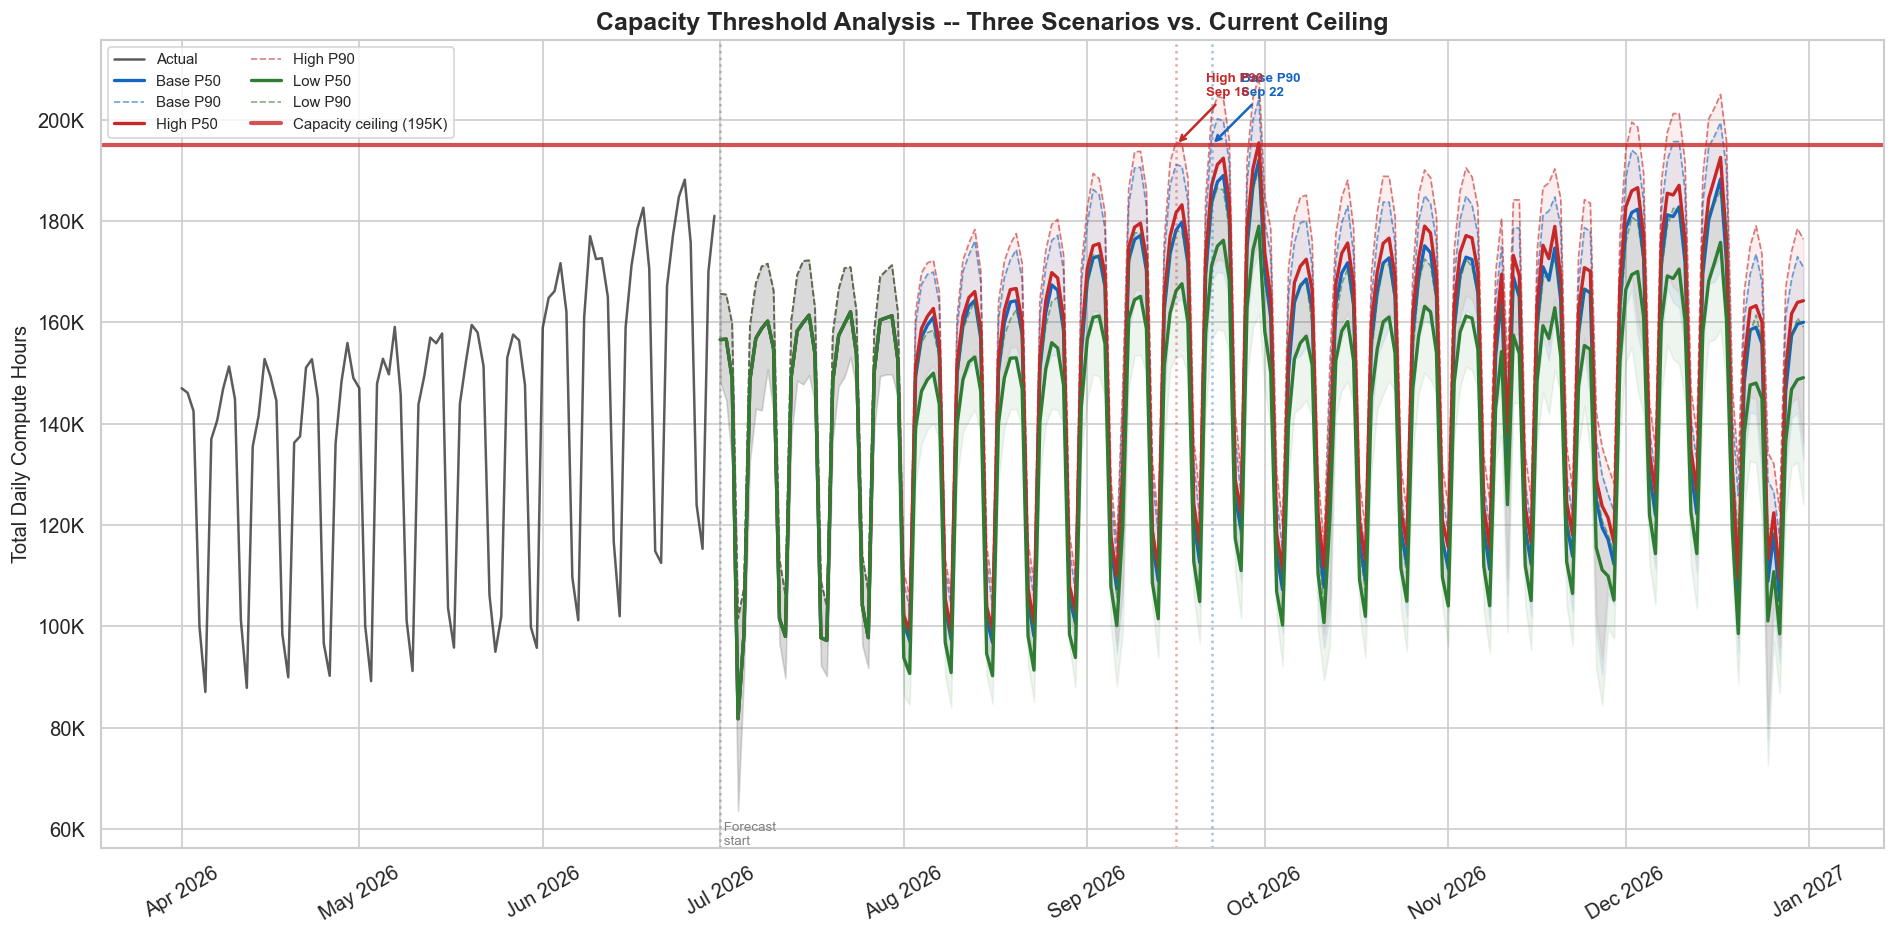

In [15]:
# THE HERO FIGURE: capacity threshold with all scenarios
# Include actuals for context
actual_context = usage[usage['date'] >= '2026-04-01'].groupby('date')['compute_hours'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 8))

# Actuals
ax.plot(actual_context['date'], actual_context['compute_hours'],
        color='#333333', linewidth=1.5, alpha=0.8, label='Actual')

# Scenarios
for scenario, color in SCENARIO_COLORS.items():
    p50_col = f'{scenario.lower()}_P50'
    p90_col = f'{scenario.lower()}_P90'
    p10_col = f'{scenario.lower()}_P10'
    ax.fill_between(scenario_daily['date'], scenario_daily[p10_col], scenario_daily[p90_col],
                    alpha=0.08, color=color)
    ax.plot(scenario_daily['date'], scenario_daily[p50_col],
            color=color, linewidth=2, label=f'{scenario} P50')
    ax.plot(scenario_daily['date'], scenario_daily[p90_col],
            color=color, linewidth=1, linestyle='--', alpha=0.6, label=f'{scenario} P90')

# Capacity ceiling
ax.axhline(CAPACITY_CEILING, color='#C62828', linewidth=2.5, linestyle='-',
           alpha=0.8, label=f'Capacity ceiling ({CAPACITY_CEILING/1_000:,.0f}K)')

# Forecast start line
ax.axvline(FORECAST_START, color='gray', linestyle=':', alpha=0.5)
ax.text(FORECAST_START, ax.get_ylim()[0], ' Forecast\n start',
        fontsize=8, color='gray', va='bottom')

# Find and annotate crossing dates
for scenario, color in SCENARIO_COLORS.items():
    p90_col = f'{scenario.lower()}_P90'
    crossings = scenario_daily[scenario_daily[p90_col] >= CAPACITY_CEILING]
    if len(crossings) > 0:
        cross_date = crossings['date'].iloc[0]
        ax.axvline(cross_date, color=color, linestyle=':', alpha=0.4)
        ax.annotate(f'{scenario} P90\n{cross_date.strftime("%b %d")}',
                    xy=(cross_date, CAPACITY_CEILING),
                    xytext=(cross_date + pd.Timedelta(days=5), CAPACITY_CEILING * 1.05),
                    fontsize=8, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

ax.set_title('Capacity Threshold Analysis -- Three Scenarios vs. Current Ceiling',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Total Daily Compute Hours')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:,.0f}K'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.xticks(rotation=30)
plt.tight_layout()
fig.savefig(FIG_DIR / 'capacity_threshold_scenarios.png', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# Print crossing dates for each scenario
print('Capacity Threshold Crossing Dates:')
print(f'  Capacity ceiling: {CAPACITY_CEILING:,.0f} hours/day')
print()

for scenario in ['Base', 'High', 'Low']:
    for quantile in ['P50', 'P90']:
        col = f'{scenario.lower()}_{quantile}'
        crossings = scenario_daily[scenario_daily[col] >= CAPACITY_CEILING]
        if len(crossings) > 0:
            cross_date = crossings['date'].iloc[0]
            days_from_now = (cross_date - FORECAST_START).days
            pct_days = (crossings[col] >= CAPACITY_CEILING).sum() / len(scenario_daily) * 100
            print(f'  {scenario:5s} {quantile}: {cross_date.strftime("%Y-%m-%d")} '
                  f'({days_from_now} days from forecast start, '
                  f'{pct_days:.0f}% of forecast days exceed ceiling)')
        else:
            print(f'  {scenario:5s} {quantile}: Does not cross within forecast horizon')

Capacity Threshold Crossing Dates:
  Capacity ceiling: 195,000 hours/day

  Base  P50: Does not cross within forecast horizon
  Base  P90: 2026-09-22 (83 days from forecast start, 5% of forecast days exceed ceiling)
  High  P50: 2026-09-30 (91 days from forecast start, 1% of forecast days exceed ceiling)
  High  P90: 2026-09-16 (77 days from forecast start, 9% of forecast days exceed ceiling)
  Low   P50: Does not cross within forecast horizon
  Low   P90: Does not cross within forecast horizon


## 7. Sensitivity Analysis

Which assumptions move the procurement timeline most? We test:
1. **Pipeline deals** -- what if each deal is certain (100%) vs. doesn't happen (0%)?
2. **Growth rate** -- what if underlying growth is 10% faster or slower?
3. **Efficiency gain magnitude** -- 10% vs 15% vs 20% reduction?

In [17]:
# Sensitivity: impact on P90 capacity crossing date
def compute_crossing_date(daily_series, threshold):
    """Find first date where series >= threshold."""
    crossings = daily_series[daily_series >= threshold].index
    return crossings[0] if len(crossings) > 0 else None

# Base P90 crossing date (reference point)
base_p90_series = scenario_daily.set_index('date')['base_P90']
base_crossing = compute_crossing_date(base_p90_series, CAPACITY_CEILING)
print(f'Base P90 crossing date: {base_crossing}')

sensitivity_results = []

# --- 1. Pipeline deal sensitivity ---
for _, deal in upcoming.iterrows():
    # Scenario: this deal is 100% certain
    test_combined = combined.copy()
    mask = (
        (test_combined['date'] >= deal['expected_date']) &
        (test_combined['compute_type'] == deal['compute_type']) &
        (test_combined['customer_segment'] == deal['customer_segment'])
    )
    # Add full (not probability-weighted) hours
    test_combined.loc[mask, 'base_P90'] += deal['estimated_daily_hours']
    test_daily = test_combined.groupby('date')['base_P90'].sum()
    deal_crossing = compute_crossing_date(test_daily, CAPACITY_CEILING)

    if base_crossing and deal_crossing:
        delta = (deal_crossing - base_crossing).days
    elif deal_crossing and not base_crossing:
        delta = -999  # brings crossing into range
    else:
        delta = 0

    sensitivity_results.append({
        'Parameter': f'Pipeline: {deal["event_name"][:30]}',
        'Test': '100% certain',
        'Days Impact': delta,
        'Category': 'Pipeline',
    })

# --- 2. Growth rate sensitivity ---
for growth_label, growth_mult in [('Growth +10%', 1.10), ('Growth -10%', 0.90)]:
    test_daily = scenario_daily.copy()
    # Approximate: scale P90 from base by growth multiplier relative to forecast start
    days_out = (test_daily['date'] - FORECAST_START).dt.days.clip(lower=0)
    growth_factor = growth_mult ** (days_out / 365)  # annualized
    test_series = (test_daily['base_P90'] * growth_factor)
    test_series.index = test_daily['date']
    growth_crossing = compute_crossing_date(test_series, CAPACITY_CEILING)

    if base_crossing and growth_crossing:
        delta = (growth_crossing - base_crossing).days
    elif growth_crossing and not base_crossing:
        delta = -999
    else:
        delta = 0

    sensitivity_results.append({
        'Parameter': growth_label,
        'Test': growth_label,
        'Days Impact': delta,
        'Category': 'Growth',
    })

# --- 3. Efficiency gain magnitude ---
for eff_label, eff_factor in [('Efficiency 10%', 0.90), ('Efficiency 20%', 0.80)]:
    test_combined = combined.copy()
    eff_mask = (
        (test_combined['compute_type'] == 'GPU Inference') &
        (test_combined['date'] >= EFFICIENCY_START)
    )
    test_combined.loc[eff_mask, 'base_P90'] *= eff_factor
    test_daily = test_combined.groupby('date')['base_P90'].sum()
    eff_crossing = compute_crossing_date(test_daily, CAPACITY_CEILING)

    if base_crossing and eff_crossing:
        delta = (eff_crossing - base_crossing).days
    elif not eff_crossing and base_crossing:
        delta = 999  # pushes crossing beyond horizon
    else:
        delta = 0

    sensitivity_results.append({
        'Parameter': eff_label,
        'Test': eff_label,
        'Days Impact': delta,
        'Category': 'Efficiency',
    })

sens_df = pd.DataFrame(sensitivity_results)
sens_df = sens_df.sort_values('Days Impact', key=abs, ascending=True)
print(sens_df[['Parameter', 'Days Impact']].to_string(index=False))

Base P90 crossing date: 2026-09-22 00:00:00
                               Parameter  Days Impact
Pipeline: TechGiant Corp GPU Training Co            0
Pipeline: FinanceAI Inference Platform M            0
Pipeline: AI Startup Cohort (YC S2026 Ba            0
Pipeline: Federal Research Computing Gra            0
Pipeline: MedTech Mid-Market Inference E            0
                             Growth -10%            1
                             Growth +10%           -6
                          Efficiency 10%          999
                          Efficiency 20%          999


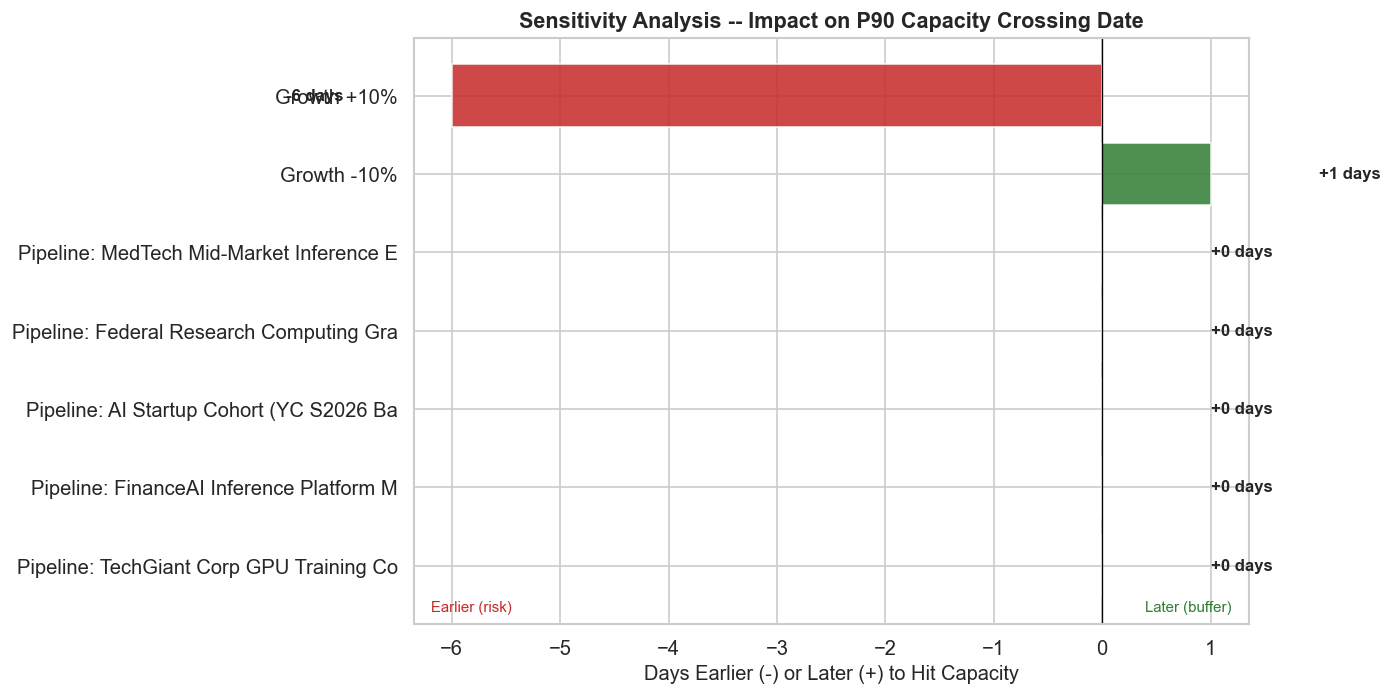

In [18]:
# Tornado chart
fig, ax = plt.subplots(figsize=(12, 6))

# Filter out extreme values for display
plot_df = sens_df[sens_df['Days Impact'].abs() < 900].copy()
plot_df = plot_df.sort_values('Days Impact', key=abs, ascending=True)

colors = ['#C62828' if d < 0 else '#2E7D32' for d in plot_df['Days Impact']]
bars = ax.barh(plot_df['Parameter'], plot_df['Days Impact'], color=colors, alpha=0.85, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Days Earlier (-) or Later (+) to Hit Capacity')
ax.set_title('Sensitivity Analysis -- Impact on P90 Capacity Crossing Date',
             fontweight='bold', fontsize=13)

# Add value labels
for bar, val in zip(bars, plot_df['Days Impact']):
    x_pos = bar.get_width()
    ha = 'left' if x_pos >= 0 else 'right'
    offset = 1 if x_pos >= 0 else -1
    ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+d} days', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.text(0.02, 0.02, 'Earlier (risk)', transform=ax.transAxes, color='#C62828', fontsize=9)
ax.text(0.98, 0.02, 'Later (buffer)', transform=ax.transAxes, color='#2E7D32', fontsize=9, ha='right')

plt.tight_layout()
fig.savefig(FIG_DIR / 'sensitivity_tornado.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Recommendations

### Procurement Decision Framework

Based on the three scenarios and sensitivity analysis:

1. **Monitor the High scenario P90 crossing date** -- this is the earliest plausible date we could run out of capacity. If pipeline deals are closing faster than expected, accelerate procurement.

2. **Pipeline deals are the biggest swing factor** -- the TechGiant contract alone can shift the timeline significantly. Sales should flag deal progress weekly to the capacity planning team.

3. **Efficiency gains provide meaningful buffer** -- if inference optimization (the 'DeepSeek moment') materializes, it buys additional runway. Worth investing in inference optimization as a hedge against procurement delays.

4. **Refresh this forecast monthly** -- retrain models, update pipeline probabilities, recalibrate conformal adjustments. The capacity threshold chart should be a living document in leadership reviews.

### Caveats

- Capacity ceiling is a simplification -- real infrastructure has per-GPU-type limits, not a single aggregate ceiling
- Pipeline probabilities are point estimates from sales -- actual conversion is uncertain
- The 'DeepSeek moment' scenario assumes a sudden, uniform 15% efficiency gain -- real efficiency improvements are typically gradual and workload-specific
- Long-horizon forecasts (months 3-6) use a calendar-only model with wider uncertainty bands

---
*End of Part 3 -- Scenario Planning*